In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob

In [13]:
# upload data to jupyter notebook
# r"C:\\data\data_*.xlsx"
file_pattern = './data/data_*.xlsx'
file_names_list = glob.glob(file_pattern)

In [14]:
file_names_list.sort()

In [15]:
file_names_list

['./data/data_1.xlsx',
 './data/data_2.xlsx',
 './data/data_3.xlsx',
 './data/data_4.xlsx',
 './data/data_5.xlsx',
 './data/data_6.xlsx']

In [4]:
type(file_names_list)

list

In [16]:
# create a list of dfs
dfs = []
for file in file_names_list:
    df = pd.read_excel(file)
    dfs.append(df)

In [17]:
dfs[0].head()

,date,contentmessage
0,2023-09-20 00:00:00,AAXX 20001 40751 42960 00301 10166 20073 38498...
1,2023-09-20 03:00:00,AAXX 20031 40751 42960 00301 10166 20073 38498...
2,2023-09-20 06:00:00,AAXX 20061 40751 12960 02002 10244 20075 38507...
3,2023-09-20 09:00:00,AAXX 20091 40751 42660 11702 10262 20078 38496...
4,2023-09-20 12:00:00,AAXX 20121 40751 12660 12202 10276 20075 38481...


In [8]:
len(dfs)

6

In [18]:
dfs[5].tail()

,date,contentmessage
228,2024-03-19 12:00:00,AAXX 19121 40751 11556 82501 10106 20062 38413...
229,2024-03-19 15:00:00,AAXX 19151 40751 41558 80602 10128 20046 38375...
230,2024-03-19 18:00:00,AAXX 19181 40751 11660 80000 10111 20060 38388...
231,2024-03-19 21:00:00,AAXX 19210 40751 42660 70000 10109 20057 38384...
232,2024-03-20 00:00:00,AAXX 20001 40751 11660 82002 10084 20067 38389...


In [19]:
df = pd.concat(dfs, ignore_index=True)

In [20]:
df.head(2)

,date,contentmessage
0,2023-09-20 00:00:00,AAXX 20001 40751 42960 00301 10166 20073 38498...
1,2023-09-20 03:00:00,AAXX 20031 40751 42960 00301 10166 20073 38498...


In [21]:
df.tail(2)

,date,contentmessage
1460,2024-03-19 21:00:00,AAXX 19210 40751 42660 70000 10109 20057 38384...
1461,2024-03-20 00:00:00,AAXX 20001 40751 11660 82002 10084 20067 38389...


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   date            1462 non-null   object
 1   contentmessage  1458 non-null   object
dtypes: object(2)
memory usage: 23.0+ KB


In [23]:
df[df.isnull().any(axis=1)]

,date,contentmessage
259,2023-10-22 06:00:00,NaN
434,2023-11-13 03:00:00,NaN
1100,2024-02-04 00:00:00,NaN
1112,2024-02-05 12:00:00,NaN


In [24]:
df.iloc[255:263]

,date,contentmessage
255,2023-10-21 18:00:00,AAXX 21181 40751 12960 20301 10153 20055 38492...
256,2023-10-21 21:00:00,AAXX 21211 40751 42960 30201 10155 20042 38487...
257,2023-10-22 00:00:00,AAXX 22001 40751 12960 30301 10134 20043 38485...
258,2023-10-22 03:00:00,AAXX 22031 40751 42960 10301 10124 20039 38492...
259,2023-10-22 06:00:00,NaN
260,2023-10-22 09:00:00,AAXX 22090 40751 42660 12202 10236 20035 38498...
261,2023-10-22 12:00:00,AAXX 22121 40751 12660 21902 10241 20015 38490...
262,2023-10-22 15:00:00,AAXX 22151 40751 42960 00201 10180 21008 38498...


In [25]:
df = df.dropna(subset='contentmessage')

In [26]:
df[df.isnull().any(axis=1)]

,date,contentmessage


In [29]:
s = df.iloc[100]['contentmessage']

In [30]:
s

'AAXX 02121 40751 12660 62502 10257 20024 38441 40070 55003 60001 81470 333 70000 81640 86460 555 10135 29022='

In [31]:
type(s)

str

In [32]:
s.find('10257')

29

In [33]:
#hard codding NOOO
# magic numbers
s[29:34]

'10257'

In [35]:
temp_idx = 29
s[temp_idx:temp_idx + 5]

'10257'

In [36]:
s

'AAXX 02121 40751 12660 62502 10257 20024 38441 40070 55003 60001 81470 333 70000 81640 86460 555 10135 29022='

In [45]:
def extract_temp(s):
    temp_idx = 29
    s = s[temp_idx:temp_idx + 5]
    if s[1] == '0':
        return float(s[2:]) / 10
    elif s[1] == '1':
        return -float(s[2:]) / 10

In [46]:
a = extract_temp(s)

In [47]:
type(a)

float

In [48]:
a

25.7

In [49]:
df1 = df.copy()

In [50]:
df1['temp'] = df1['contentmessage'].apply(extract_temp)

IndexError: string index out of range

In [51]:
df1

,date,contentmessage
0,2023-09-20 00:00:00,AAXX 20001 40751 42960 00301 10166 20073 38498...
1,2023-09-20 03:00:00,AAXX 20031 40751 42960 00301 10166 20073 38498...
2,2023-09-20 06:00:00,AAXX 20061 40751 12960 02002 10244 20075 38507...
3,2023-09-20 09:00:00,AAXX 20091 40751 42660 11702 10262 20078 38496...
4,2023-09-20 12:00:00,AAXX 20121 40751 12660 12202 10276 20075 38481...
...,...,...
1457,2024-03-19 12:00:00,AAXX 19121 40751 11556 82501 10106 20062 38413...
1458,2024-03-19 15:00:00,AAXX 19151 40751 41558 80602 10128 20046 38375...
1459,2024-03-19 18:00:00,AAXX 19181 40751 11660 80000 10111 20060 38388...
1460,2024-03-19 21:00:00,AAXX 19210 40751 42660 70000 10109 20057 38384...


In [53]:
a = df1.head(10)

In [54]:
a['temp'] =a['contentmessage'].apply(extract_temp)

/tmp/ipykernel_154965/1103574717.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a['temp'] =a['contentmessage'].apply(extract_temp)


In [55]:
a

,date,contentmessage,temp
0,2023-09-20 00:00:00,AAXX 20001 40751 42960 00301 10166 20073 38498...,16.6
1,2023-09-20 03:00:00,AAXX 20031 40751 42960 00301 10166 20073 38498...,16.6
2,2023-09-20 06:00:00,AAXX 20061 40751 12960 02002 10244 20075 38507...,24.4
3,2023-09-20 09:00:00,AAXX 20091 40751 42660 11702 10262 20078 38496...,26.2
4,2023-09-20 12:00:00,AAXX 20121 40751 12660 12202 10276 20075 38481...,27.6
5,2023-09-20 15:00:00,AAXX 20151 40751 42960 00000 10228 20066 38479...,22.8
6,2023-09-20 18:00:00,AAXX 20181 40751 12960 00401 10201 20068 38492...,20.1
7,2023-09-20 21:00:00,AAXX 20211 40751 42960 00201 10203 20055 38490...,20.3
8,2023-09-21 00:00:00,AAXX 21001 40751 12960 00301 10176 20059 38487...,17.6
9,2023-09-21 03:00:00,AAXX 21031 40751 42960 00301 10162 20058 38492...,16.2


In [58]:
def extract_temp(s):
    temp_idx = 29
    if len(s) >= temp_idx + 5:
        s = s[temp_idx:temp_idx + 5]
        if s.isdigit and s[0] in ['1']:
            if s[1] == '0':
                return float(s[2:]) / 10
            elif s[1] == '1':
                return -float(s[2:]) / 10
        else:
            return np.nan
    else:
        return np.nan
        
        
    
    

In [56]:
'10111'.isdigit()

True

In [57]:
"amir".isdigit()

False

In [59]:
df1['temp'] = df1['contentmessage'].apply(extract_temp)

In [60]:
df1.head()

,date,contentmessage,temp
0,2023-09-20 00:00:00,AAXX 20001 40751 42960 00301 10166 20073 38498...,16.6
1,2023-09-20 03:00:00,AAXX 20031 40751 42960 00301 10166 20073 38498...,16.6
2,2023-09-20 06:00:00,AAXX 20061 40751 12960 02002 10244 20075 38507...,24.4
3,2023-09-20 09:00:00,AAXX 20091 40751 42660 11702 10262 20078 38496...,26.2
4,2023-09-20 12:00:00,AAXX 20121 40751 12660 12202 10276 20075 38481...,27.6


In [61]:
df1.drop(columns='contentmessage', inplace=True)

In [62]:
df1.head()

,date,temp
0,2023-09-20 00:00:00,16.6
1,2023-09-20 03:00:00,16.6
2,2023-09-20 06:00:00,24.4
3,2023-09-20 09:00:00,26.2
4,2023-09-20 12:00:00,27.6


In [63]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1458 entries, 0 to 1461
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    1458 non-null   object 
 1   temp    1433 non-null   float64
dtypes: float64(1), object(1)
memory usage: 34.2+ KB


In [64]:
df1[df1.isnull().any(axis=1)]

,date,temp
99,2023-10-02 09:00:00,NaN
185,2023-10-13 03:00:00,NaN
480,2023-11-18 21:00:00,NaN
506,2023-11-22 00:00:00,NaN
752,2023-12-22 15:00:00,NaN
1096,2024-02-03 12:00:00,NaN
1116,2024-02-06 00:00:00,NaN
1273,2024-02-25 12:00:00,NaN
1279,2024-02-26 06:00:00,NaN
1281,2024-02-26 12:00:00,NaN


In [65]:
df1.iloc[95: 110]

,date,temp
95,2023-10-01 21:00:00,16.6
96,2023-10-02 00:00:00,15.2
97,2023-10-02 03:00:00,13.8
98,2023-10-02 06:00:00,24.8
99,2023-10-02 09:00:00,NaN
100,2023-10-02 12:00:00,25.7
101,2023-10-02 15:00:00,21.1
102,2023-10-02 18:00:00,19.9
103,2023-10-02 21:00:00,17.8
104,2023-10-03 00:00:00,16.1


In [66]:
df1['temp'] = df1['temp'].interpolate()

In [67]:
df1.iloc[95: 110]

,date,temp
95,2023-10-01 21:00:00,16.60
96,2023-10-02 00:00:00,15.20
97,2023-10-02 03:00:00,13.80
98,2023-10-02 06:00:00,24.80
99,2023-10-02 09:00:00,25.25
100,2023-10-02 12:00:00,25.70
101,2023-10-02 15:00:00,21.10
102,2023-10-02 18:00:00,19.90
103,2023-10-02 21:00:00,17.80
104,2023-10-03 00:00:00,16.10


In [68]:
df1.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
temp,1458.0,10.456276,6.635037,-5.5,5.3,9.9,14.675,29.3


In [69]:
import seaborn as sns

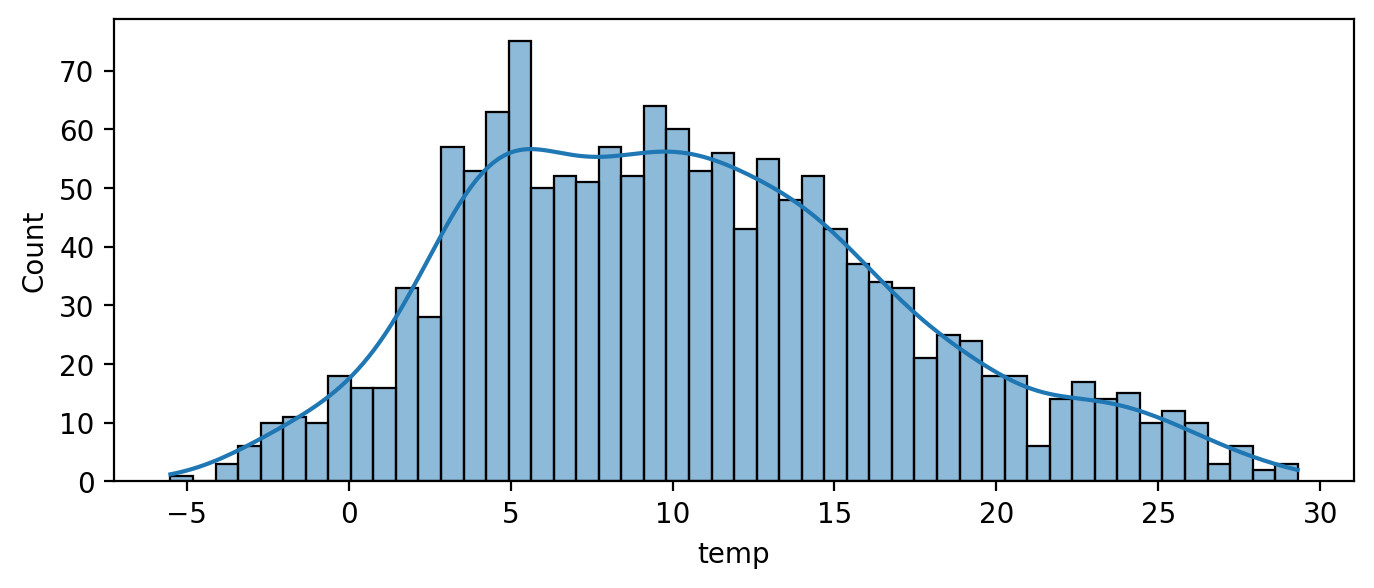

In [74]:
plt.figure(figsize=(8, 3), dpi=200)
sns.histplot(data=df1, x='temp', bins=50, kde=True)
plt.show()

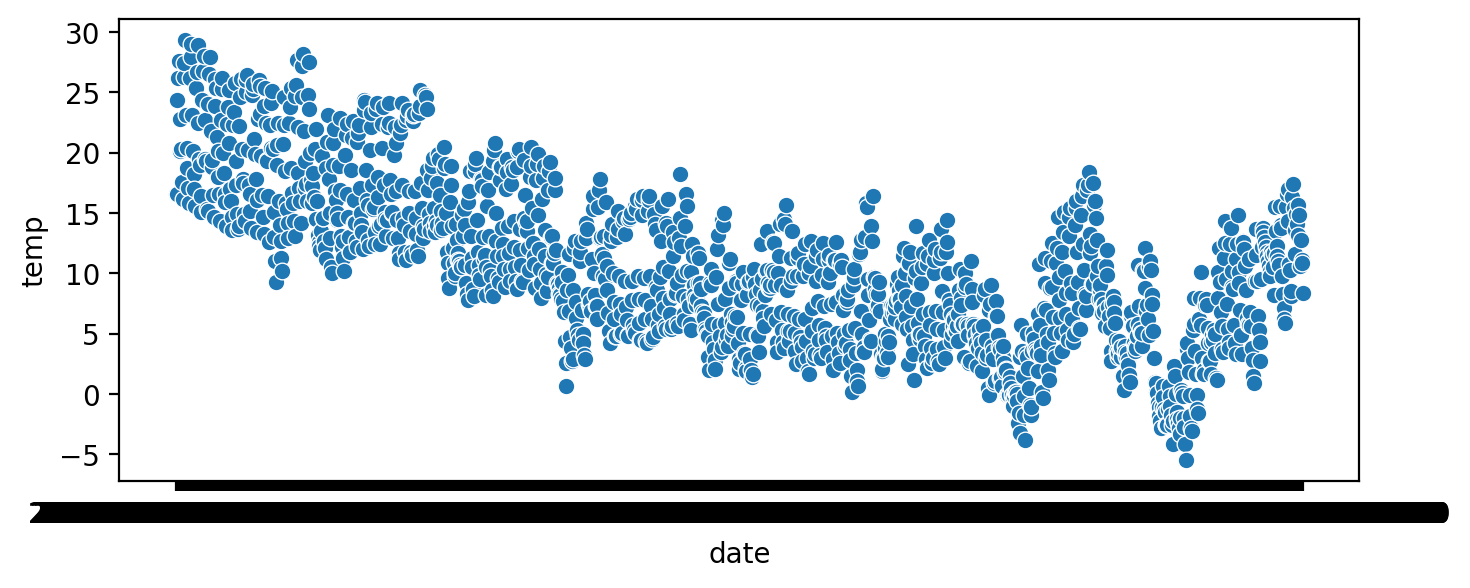

In [75]:
plt.figure(figsize=(8, 3), dpi=200)
sns.scatterplot(data=df1, x='date', y='temp')
plt.show()

In [76]:
output_path = 'data_temp_cleaned.xlsx'
df1.to_excel(output_path, index=False)